# Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = pd.read_csv(r"C:\Users\Anders\Downloads\iris.csv")

# Check for missing values
iris.info()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Anders\\Downloads\\iris.csv'

# Preprocessing

In [ ]:
# Handle rows with missing values
iris.dropna(inplace=True)

# Shuffle data (så rækkefølgen ikke betyder noget)
# frac=1 betyder "alle rækker, men i tilfældig rækkefølge"
iris = iris.sample(frac=1, random_state=42).reset_index(drop=True)

### Opgave 5: Juster antallet af features.
#   F.eks. feature 1 til 3: X = iris.iloc[:, 1:3].values eller
#   F.eks. inkluder alle features: X = iris.iloc[:, :].values eller

# Define data
X = iris.iloc[:, 0:2].values  # we only take the first two features for visualization purposes
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Opgave 4: Tag et subsample af data, f.eks. 25 samples
# X_train_small, y_train_small = X_train[:25], y_train[:25]

# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
# Opgave 4:
# scaler_small  = StandardScaler()
# X_train_small_std = scaler_small.fit_transform(X_train_small)
# X_test_std = scaler_small.transform(X_test)

# Model training

In [ ]:
# Train kNN classifier

### Opgave 3: Juster antallet af naboer.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)
### Opgave 4: Husk at opdater til X_train_small og y_train_small i opgave 4: 
# knn.fit(X_train_small_std, y_train_small)

# Train Naive Bayes classifier
nb = GaussianNB()
nb.fit(X_train_std, y_train);
### Opgave 4: 
# nb.fit(X_train_small_std, y_train_small);

# Testing the model

In [ ]:
# Calculate accuracy for training and testing sets
knn_train_accuracy = accuracy_score(y_train, knn.predict(X_train_std))
# Opgave 4: 
# knn_train_accuracy_small = accuracy_score(y_train_small, knn.predict(X_train_small_std))
knn_test_accuracy = accuracy_score(y_test, knn.predict(X_test_std))

nb_train_accuracy = accuracy_score(y_train, nb.predict(X_train_std))
# Opgave 4: 
# nb_train_accuracy_small = accuracy_score(y_train_small, nb.predict(X_train_small_std))
nb_test_accuracy = accuracy_score(y_test, nb.predict(X_test_std))

print("kNN Training Accuracy:", round(knn_train_accuracy, 2))
# Opgave 4:
# # print("kNN Training Accuracy (small):", round(knn_train_accuracy_small, 2))
print("kNN Testing Accuracy:", round(knn_test_accuracy, 2))

print("Naive Bayes Training Accuracy:", round(nb_train_accuracy, 2))
# Opgave 4:
# print("Naive Bayes Training Accuracy (small):", round(nb_train_accuracy_small, 2))
print("Naive Bayes Testing Accuracy:", round(nb_test_accuracy, 2))

kNN Training Accuracy: 0.79
kNN Testing Accuracy: 0.77
Naive Bayes Training Accuracy: 0.77
Naive Bayes Testing Accuracy: 0.77


## Opgave 3

kNN Training Accuracy: 0.78
kNN Testing Accuracy: 0.84


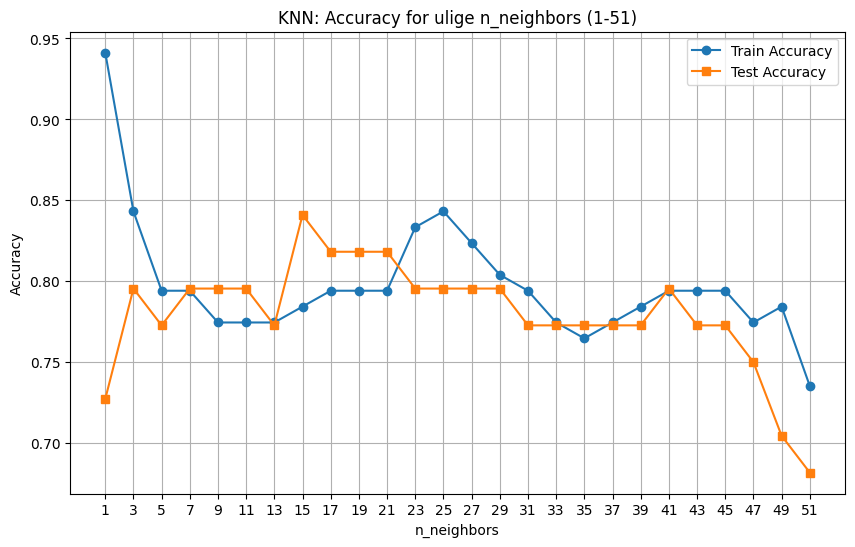

In [ ]:
### Simpel løsning: Prøv forskellige værdier af n_neighbors og se hvad der sker: 
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_std, y_train)

knn_train_accuracy = accuracy_score(y_train, knn.predict(X_train_std))
knn_test_accuracy = accuracy_score(y_test, knn.predict(X_test_std))

print("kNN Training Accuracy:", round(knn_train_accuracy, 2))
print("kNN Testing Accuracy:", round(knn_test_accuracy, 2))


### Mere kompliceret - Afprøv en række af n_neighbors værdier og plot resultaterne 
neighbors_list = list(range(1,52, 2))  # 1,3,5,...,51

train_acc_list = []
test_acc_list = []

for k in neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train_std))
    test_acc = accuracy_score(y_test, knn.predict(X_test_std))
    
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

plt.figure(figsize=(10,6))
plt.plot(neighbors_list, train_acc_list, marker='o', label='Train Accuracy')
plt.plot(neighbors_list, test_acc_list, marker='s', label='Test Accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy for ulige n_neighbors (1-51)')
plt.xticks(neighbors_list)
plt.grid(True)
plt.legend()
plt.show()

## Opgave 4

In [ ]:
X_train_small, y_train_small = X_train[:30], y_train[:30]

scaler_small  = StandardScaler()
X_train_small_std = scaler_small.fit_transform(X_train_small)
X_test_std = scaler_small.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_small_std, y_train_small)

knn_train_accuracy_small = accuracy_score(y_train_small, knn.predict(X_train_small_std))
knn_test_accuracy_small = accuracy_score(y_test, knn.predict(X_test_std))

print("kNN Training Accuracy (small training sample):", round(knn_train_accuracy_small, 2))
print("kNN Testing Accuracy (small training sample):", round(knn_test_accuracy_small, 2))

print("kNN Training Accuracy:", round(knn_train_accuracy, 2))
print("kNN Testing Accuracy:", round(knn_test_accuracy, 2))

kNN Training Accuracy (small training sample): 0.67
kNN Testing Accuracy (small training sample): 0.59
kNN Training Accuracy: 0.78
kNN Testing Accuracy: 0.84


## Opgave 5

kNN Training Accuracy (small training sample): 0.88
kNN Testing Accuracy (small training sample): 0.77


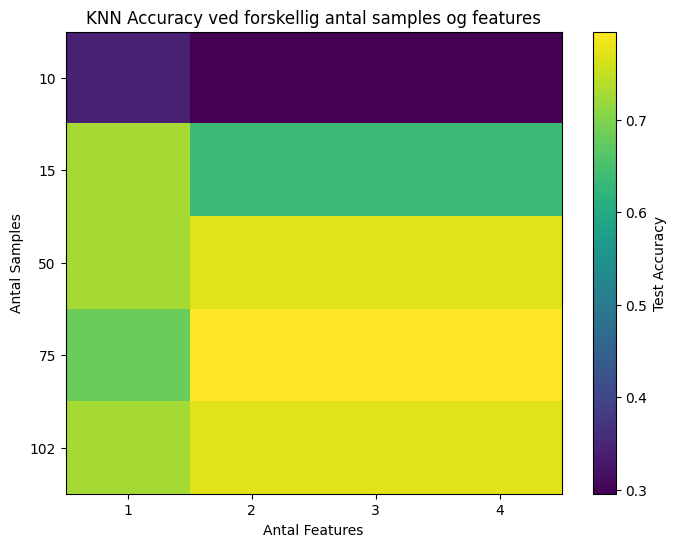

In [ ]:
### Simple løsning: Prøv forskellige værdier af antal træningsdata og features og se hvad der sker:
number_of_samples = 50
X_train_small, y_train_small = X_train[:number_of_samples], y_train[:number_of_samples]

number_of_features = 2
X_train_small, X_test_small = X_train_small[:, 0:number_of_features], X_test[:, 0:number_of_features]

scaler = StandardScaler()
X_train_small_std = scaler.fit_transform(X_train_small)
X_test_small_std = scaler.transform(X_test_small)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_small_std, y_train_small)

knn_train_accuracy = accuracy_score(y_train_small, knn.predict(X_train_small_std))
knn_test_accuracy = accuracy_score(y_test, knn.predict(X_test_small_std))

print("kNN Training Accuracy (small training sample):", round(knn_train_accuracy, 2))
print("kNN Testing Accuracy (small training sample):", round(knn_test_accuracy, 2))

### Mere kompliceret - Afprøv en række af kombinationer og plot resultaterne 
sample_sizes = [10, 15, 50, 75, len(X_train)]
feature_counts = [1, 2, 3, 4]

results = np.zeros((len(sample_sizes), len(feature_counts)))

for i, n_samples in enumerate(sample_sizes):
    for j, n_features in enumerate(feature_counts):
        # Lav subset
        X_train_small = X_train[:n_samples, :n_features]
        y_train_small = y_train[:n_samples]
        X_test_small = X_test[:, :n_features]

        # Standardize
        scaler = StandardScaler()
        X_train_small_std = scaler.fit_transform(X_train_small)
        X_test_small_std = scaler.transform(X_test_small)

        # Train KNN
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_small_std, y_train_small)

        # Gem test accuracy
        test_acc = accuracy_score(y_test, knn.predict(X_test_small_std))
        results[i, j] = test_acc


plt.figure(figsize=(8,6))
im = plt.imshow(results, cmap="viridis", aspect="auto")

plt.colorbar(im, label="Test Accuracy")
plt.xticks(np.arange(len(feature_counts)), feature_counts)
plt.yticks(np.arange(len(sample_sizes)), sample_sizes)
plt.xlabel("Antal Features")
plt.ylabel("Antal Samples")
plt.title("KNN Accuracy ved forskellig antal samples og features")
plt.show()

# Visualize decision boundary

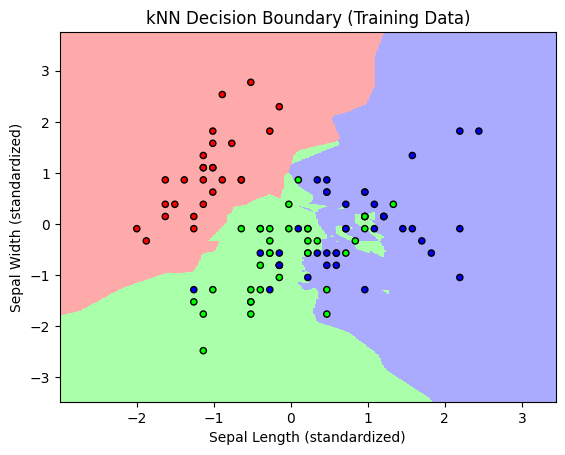

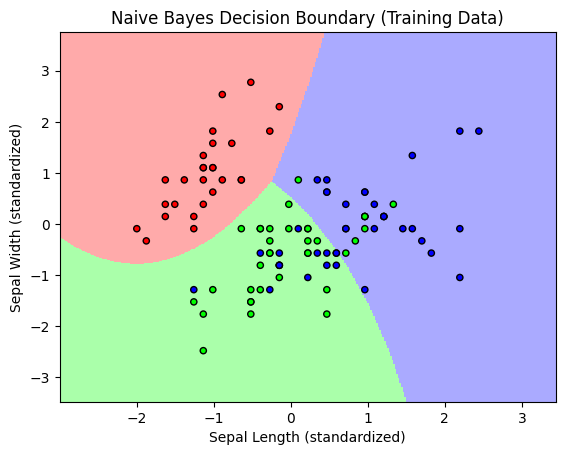

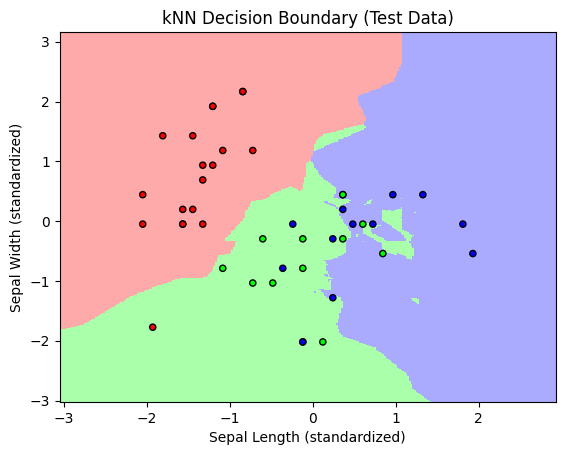

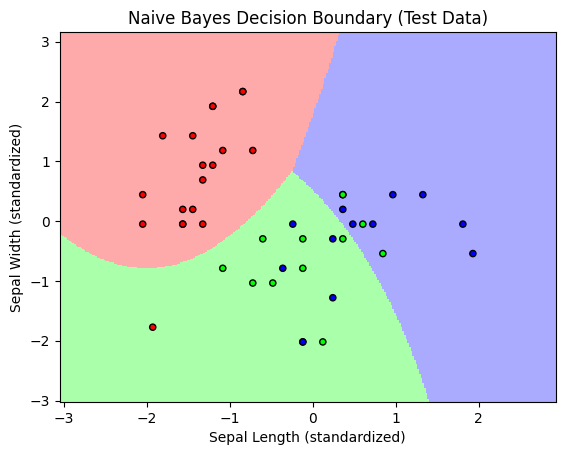

In [ ]:
# Define a colormap for plotting decision regions
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Function to plot the decision boundaries
def plot_decision_boundary(classifier, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Sepal Length (standardized)')
    plt.ylabel('Sepal Width (standardized)')
    plt.title(title)


# Plot decision boundaries with training data

### Opgave 4: Husk at opdater til X_train_small_std og y_train_small i opgave 4:
plot_decision_boundary(knn, X_train_std, y_train, 'kNN Decision Boundary (Training Data)')
plt.show()

plot_decision_boundary(nb, X_train_std, y_train, 'Naive Bayes Decision Boundary (Training Data)')
plt.show()

# Plot decision boundaries with test data
plot_decision_boundary(knn, X_test_std, y_test, 'kNN Decision Boundary (Test Data)')
plt.show()

plot_decision_boundary(nb, X_test_std, y_test, 'Naive Bayes Decision Boundary (Test Data)')
plt.show()